In [1]:
import os
try:
    path_initialized
except NameError:
    path_initialized = True
    os.chdir('..')

import numpy as np
from sympy.abc import x, y

# from qldpc import codes
import networkx as nx
import matplotlib.pyplot as plt
import stim
import pickle
import sinter
from copy import deepcopy
import scipy

import src.device as device
import src.plotting as plotter
import src.stim_dag as stim_dag

from src.RotatedSurfaceCode import RotatedSurfaceCode
from src.TileCode import TileCode
from src.HGPCode import HGPCode
from src.RadialCode import RadialCode
from src.GBCode import GBCode
from src.HypercubeCode import HypercubeCode
from src.decoders import BPOSD

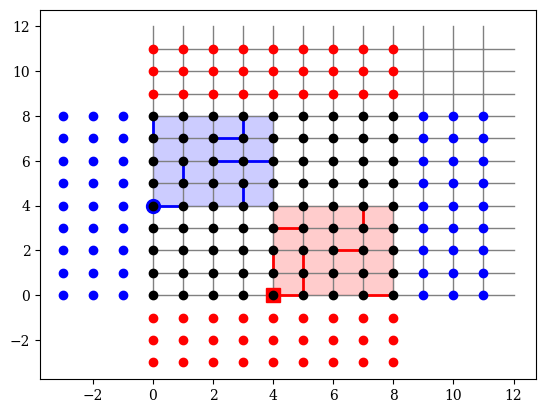

In [2]:
code_tile = TileCode.known_code(288, 18, 13)
code_tile.plot_construction()

In [3]:
len(code_tile._qubit_edges)

288

In [ ]:
code_tile = TileCode.known_code(288, 18, 13)

buffer_x = 8
buffer_y = 4
xmax,ymax = 0,0
data_coords = dict()
for i in code_tile.data_indices:
    x,y = code_tile.qubit_coords[i]
    data_coords[i] = (x+buffer_x, y+buffer_y)
    xmax = max(xmax, x)
    ymax = max(ymax, y)

dev = device.UnitCellDevice(xmax+2*buffer_x, ymax+2*buffer_y, device.default_hwp, debug=False)

sched_tile = dev.compile_QEC_schedule(
    code_tile,
    data_coords,
    [],
    rounds=1,
    use_highways=False,
    refocus_shuttle_noise=True,
    scheduling_method=device.SchedulingMethod('GREEDY'),
    separate_X_Z=True,
    force_overwrite_cache=True,
)

circ = sched_tile.to_stim_circuit(code_tile, 'X', device.error_params(1e-3, 1e-3, 1e-3), XYZ_decode=False)

circ.detector_error_model()

Optimizing 135 ancilla schedules.......................................................................................................................................
Optimizing 135 ancilla schedules.......................................................................................................................................


stim.DetectorErrorModel('''
    error(0.0020308) D0 D18 D58 D59
    error(0.0020308) D0 D30 D31 D95
    error(0.00820581) D0 D135
    error(0.0020308) D1
    error(0.0020308) D1 D19 D95 D115
    error(0.00820581) D1 D136
    error(0.0020308) D2 D14 D58 L1 L2 L4 L5 L6 L7 L11 L13 L14 L16 L17
    error(0.0020308) D2 D34 D35 D115
    error(0.00820581) D2 D137
    error(0.0020308) D3 D17 D91 D111
    error(0.0020308) D3 D31 D89
    error(0.00820581) D3 D138
    error(0.0020308) D4 D36 D38 D58
    error(0.0020308) D4 D63 L2 L3 L5 L7 L8 L10 L11 L12 L15 L17
    error(0.00820581) D4 D139
    error(0.0020308) D5
    error(0.0020308) D5 D13 D59 D89
    error(0.00820581) D5 D140
    error(0.0020308) D6 D16 D63 D91
    error(0.0020308) D6 D34 D37 D59
    error(0.00820581) D6 D141
    error(0.0020308) D7 D35 D38 D91
    error(0.0020308) D7 D101 L1 L3 L5 L6 L7 L8 L9 L11 L14 L15 L17
    error(0.00820581) D7 D142
    error(0.0020308) D8 D15 D101 D115
    error(0.00610578) D8 D30 D37 D111
    error(0.00

In [12]:
sched_tile.total_duration()

46200

In [13]:
sched_tile.instruction_start_times

[0,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,
 500,


In [14]:
frames = sched_tile.get_frames(500)

Issue at t=1500
	Overlapping: [373, 431] at pos (30.6, 3.8)
	Overlapping: [378, 447] at pos (26.6, 5.8)
	Overlapping: [379, 529] at pos (28.6, 5.8)
	Overlapping: [391, 466] at pos (28.6, 7.8)
	Overlapping: [403, 457] at pos (28.6, 9.8)
	Overlapping: [421, 476] at pos (30.6, 11.8)
	Overlapping: [422, 485] at pos (30.6, 12.8)
	Overlapping: [373, 431] at pos (30.6, 3.8)
	Overlapping: [378, 447] at pos (26.6, 5.8)
	Overlapping: [403, 457] at pos (28.6, 9.8)
	Overlapping: [391, 466] at pos (28.6, 7.8)
	Overlapping: [421, 476] at pos (30.6, 11.8)
	Overlapping: [422, 485] at pos (30.6, 12.8)
	Overlapping: [379, 529] at pos (28.6, 5.8)
Issue at t=2500
	Overlapping: [431, 512] at pos (30.6, 3.8)
	Overlapping: [431, 512] at pos (30.6, 3.8)
Issue at t=3000
	Overlapping: [431, 512] at pos (30.6, 3.8)
	Overlapping: [431, 512] at pos (30.6, 3.8)
Issue at t=4500
	Overlapping: [350, 421] at pos (30.0, 13.0)
	Overlapping: [350, 421] at pos (30, 13)
Issue at t=6000
	Overlapping: [486, 540] at pos (14.6,

MovieWriter imagemagick unavailable; using Pillow instead.


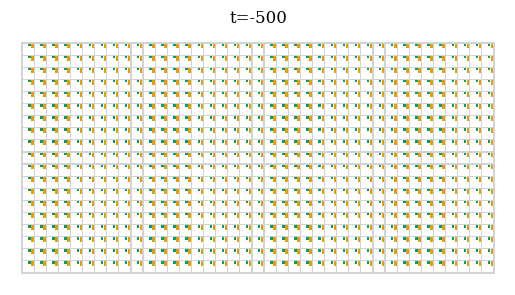

In [15]:
anim = plotter.animate_device(dev, code_tile, frames, 'anim_tile_greedy.gif', fps=2)